## Odds ratio analysis of gene loss and duplication

Testing whether the odds that genes in an orthogroup are missing, in single copy, or in multiple copies differs significantly between orb-weavers and non-orb-weavers - using BUSCO scores as a weight for confidence in each species' transcriptome

#### import modules

In [ ]:
import os
import sys

# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))

if src_path not in sys.path:
    sys.path.append(src_path)

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data")
results = os.path.join(scripts, "..", "results")
assets = os.path.join(scripts, "..", "assets")

# Import the odds_ratio_test
import odds_ratio_test as ort

In [2]:
%load_ext autoreload
%autoreload 2

#### specify input files

In [2]:
genecount_csv = f"{assets}/N5.GeneCount.tsv"
orb_list_filename = f"{assets}/orbweavers-list.txt"
hog_node_genes_tsv = f"{assets}/N5.tsv"

Testing for loss of genes first, using occupancy threshold of 75 (same as HyPhy analysis)

Also using a maximum occupancy of N-3 = 95 so there can be some meaningful comparison of loss between the test groups.

Testing skew, mean, and standard deviation, first using a left-tailed alternative hypothesis

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 50 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



  0%|          | 0/10000 [00:00<?, ?it/s]


Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8080

Filtering log odds ratio results df for occupancy >= 50, <= 95
and log odds ratio threshold [-1.38368301  1.38751649]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *50* and maximum occupancy *95* 
Analysis run on 2026-01-29 at 14:06:01
Foreground list: /Users/calvin/orb-selection/scripts/../assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6437248014800722
True standard deviation: 1.485743504479298
True skew: 0.18232428922267216

*

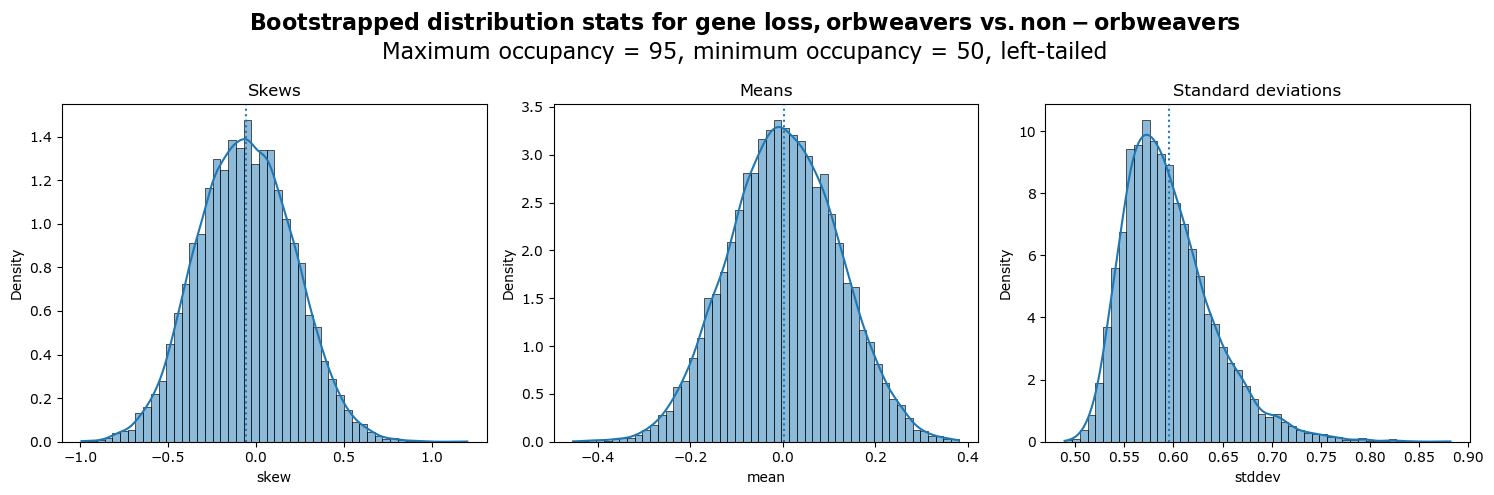

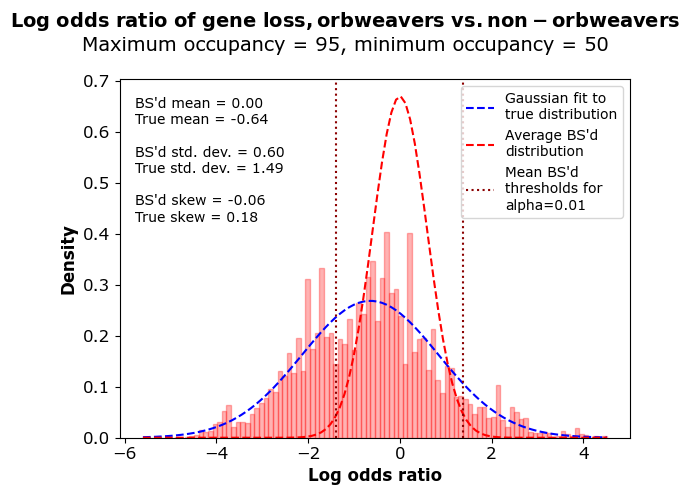

In [ ]:
loss_lt_50_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=50,
    max_occ=95, 
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=f"{results}/odds_ratio_test/occ_50_busco",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    buscos_filename=f"{assets}/buscos.csv"
)

Repeat without BUSCO scaling for comparison

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 50 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



  0%|          | 0/10000 [00:00<?, ?it/s]


Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8123

Filtering log odds ratio results df for occupancy >= 50, <= 95
and log odds ratio threshold [-1.38599666  1.3870613 ]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *50* and maximum occupancy *95* 
Analysis run on 2026-01-29 at 14:12:44
Foreground list: /Users/calvin/orb-selection/scripts/../assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6629752260879564
True standard deviation: 1.5413813505684821
True skew: 0.19332320037856815



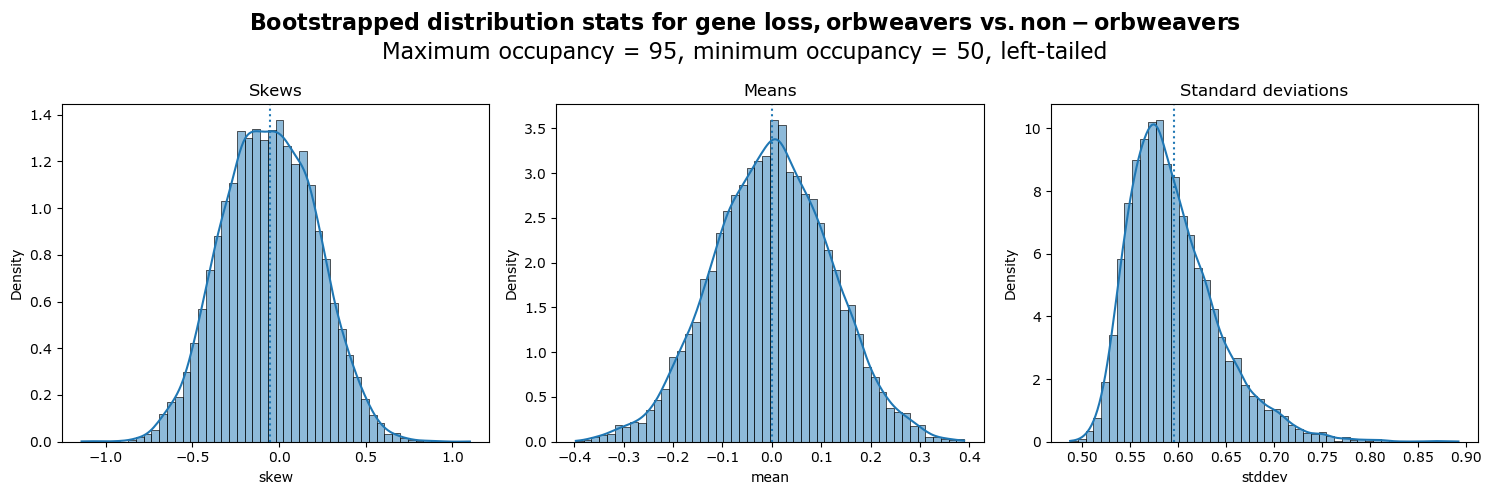

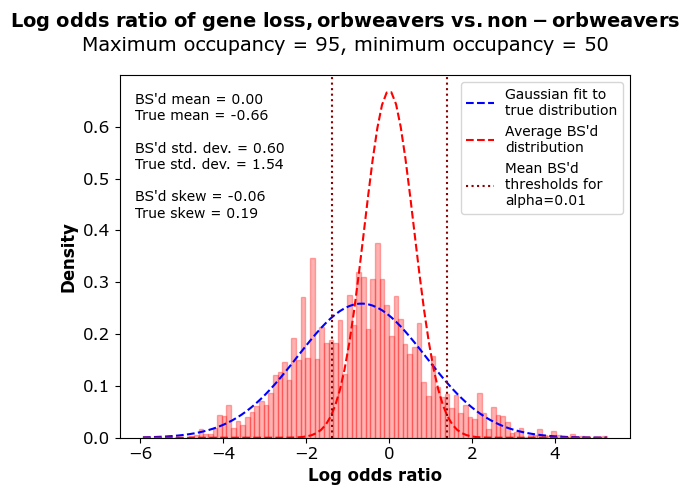

In [ ]:
loss_lt_50_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=50,
    max_occ=95, 
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=f"{results}/odds_ratio_test/occ_50_no_busco",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
)

Testing for duplication of genes, using minimum occupancy threshold of 50, no max occupancy.

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 50 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups EXCEED
the true distribution's statistics (right-tailed)...



  0%|          | 0/10000 [00:00<?, ?it/s]


Bootstrapping counter for MEAN: 3219
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 2662

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-1.52917175  1.53369268]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2026-01-29 at 14:16:48
Foreground list: /Users/calvin/orb-selection/scripts/../assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: 0.02785106946820591
True standard deviation: 0.8952757910525697
True skew: 0.014699525736

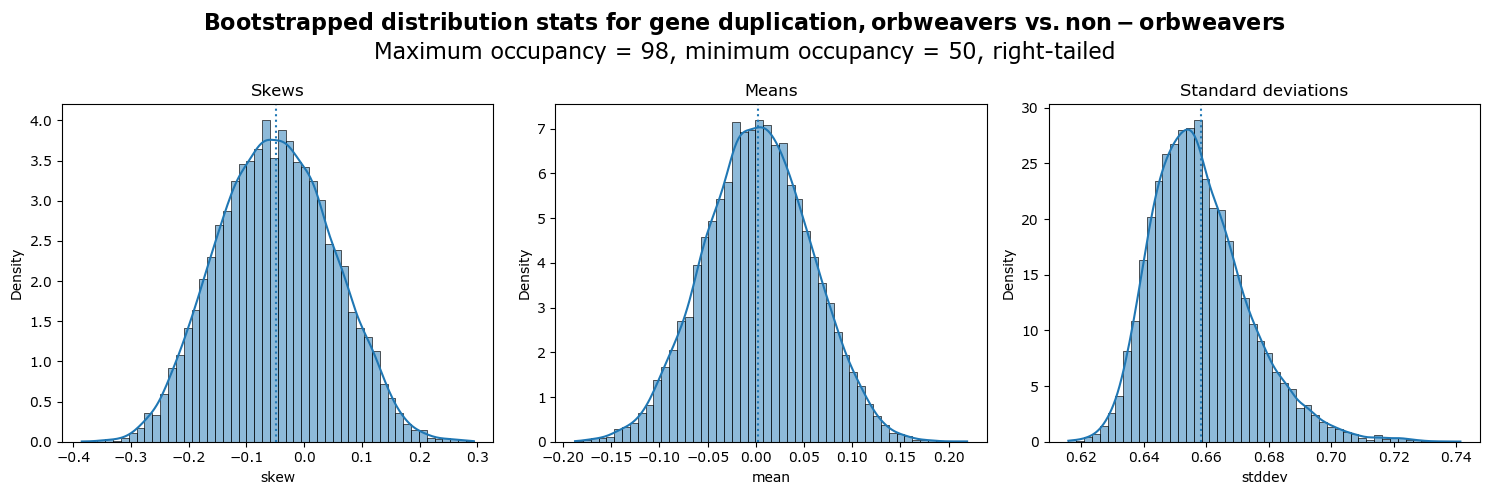

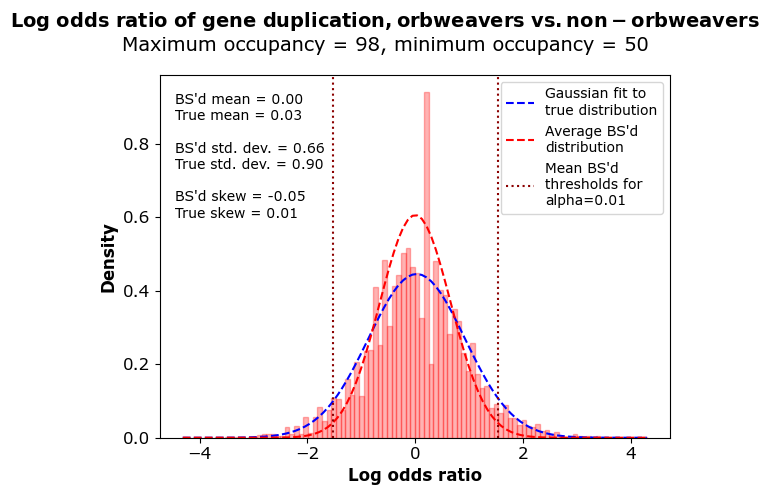

In [ ]:
dup_rt_50_98 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "duplication",
    genecount_csv=genecount_csv,
    occupancy_threshold=50,
    alpha=0.01,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=f"{results}/odds_ratio_test/occ_50_busco",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    buscos_filename=f"{assets}/buscos.csv"
)